In [1]:
import pandas as pd

# Raw GitHub URL for the features.csv dataset
#url = 'https://raw.githubusercontent.com/Vivek909065/Sales_Forcasting/main/Dataset/features.csv'
url = 'https://raw.githubusercontent.com/Vivek909065/Sales_Forcasting/main/Dataset/Walmart_Sales.csv'

try:
    df = pd.read_csv(url)
    print("Dataset loaded successfully!")
    print(df.head())
except Exception as e:
    print(f"Error loading the dataset: {e}")

Dataset loaded successfully!
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


In [2]:
print("Original DataFrame shape:", df.shape)
df_cleaned = df.dropna()
print("DataFrame shape after dropping null/NaN values:", df_cleaned.shape)
print("First 5 rows of cleaned DataFrame:")
print(df_cleaned.head())

Original DataFrame shape: (6435, 8)
DataFrame shape after dropping null/NaN values: (6435, 8)
First 5 rows of cleaned DataFrame:
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


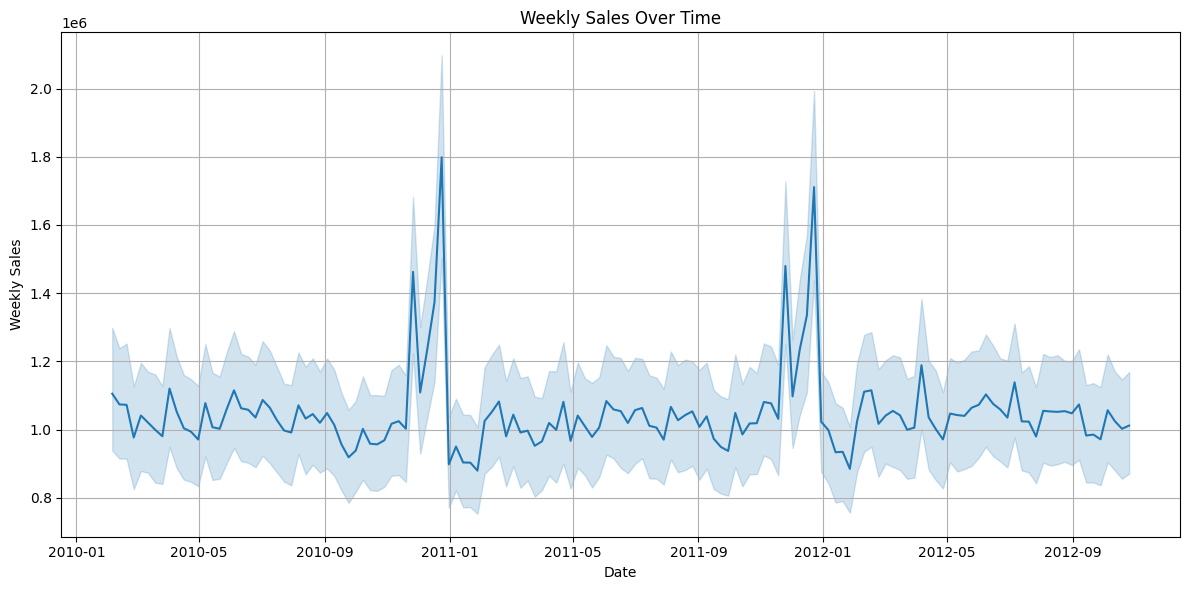

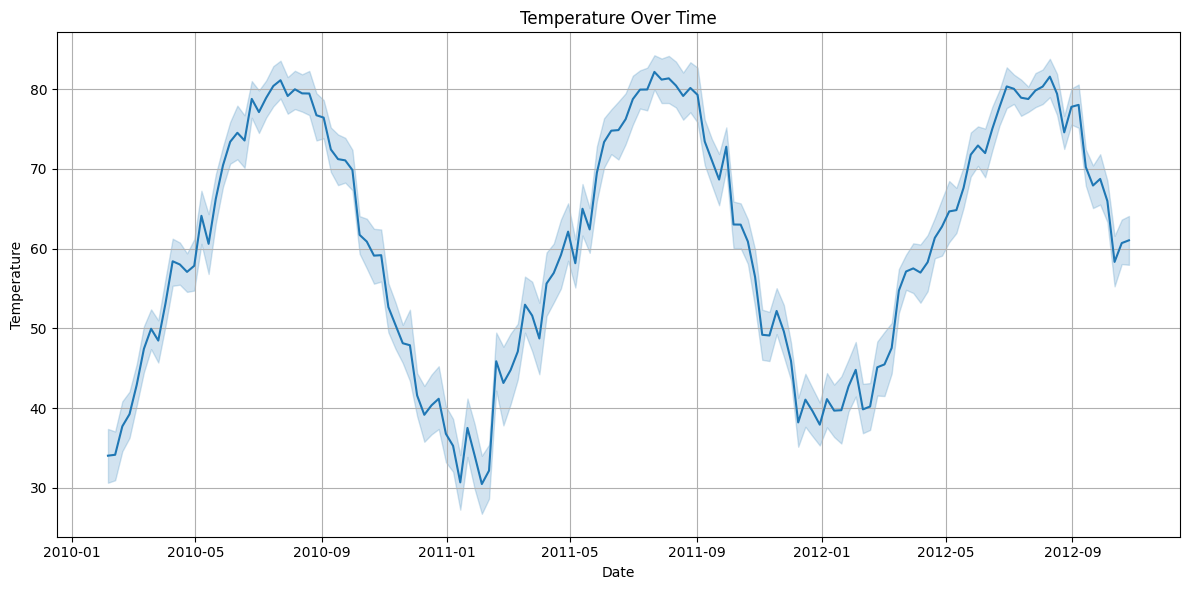

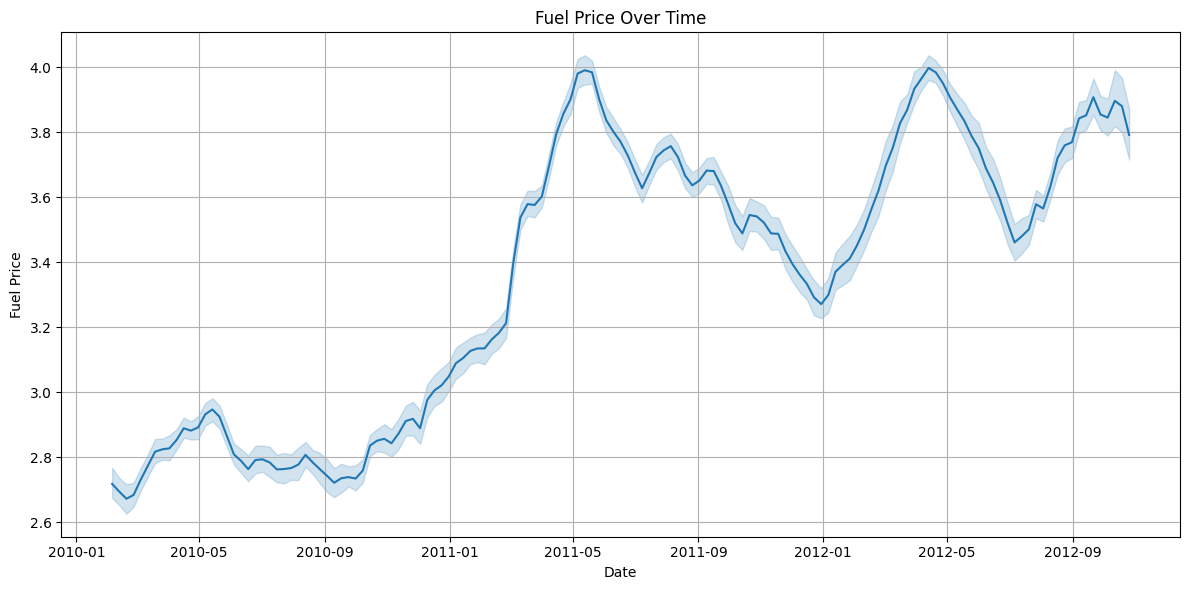

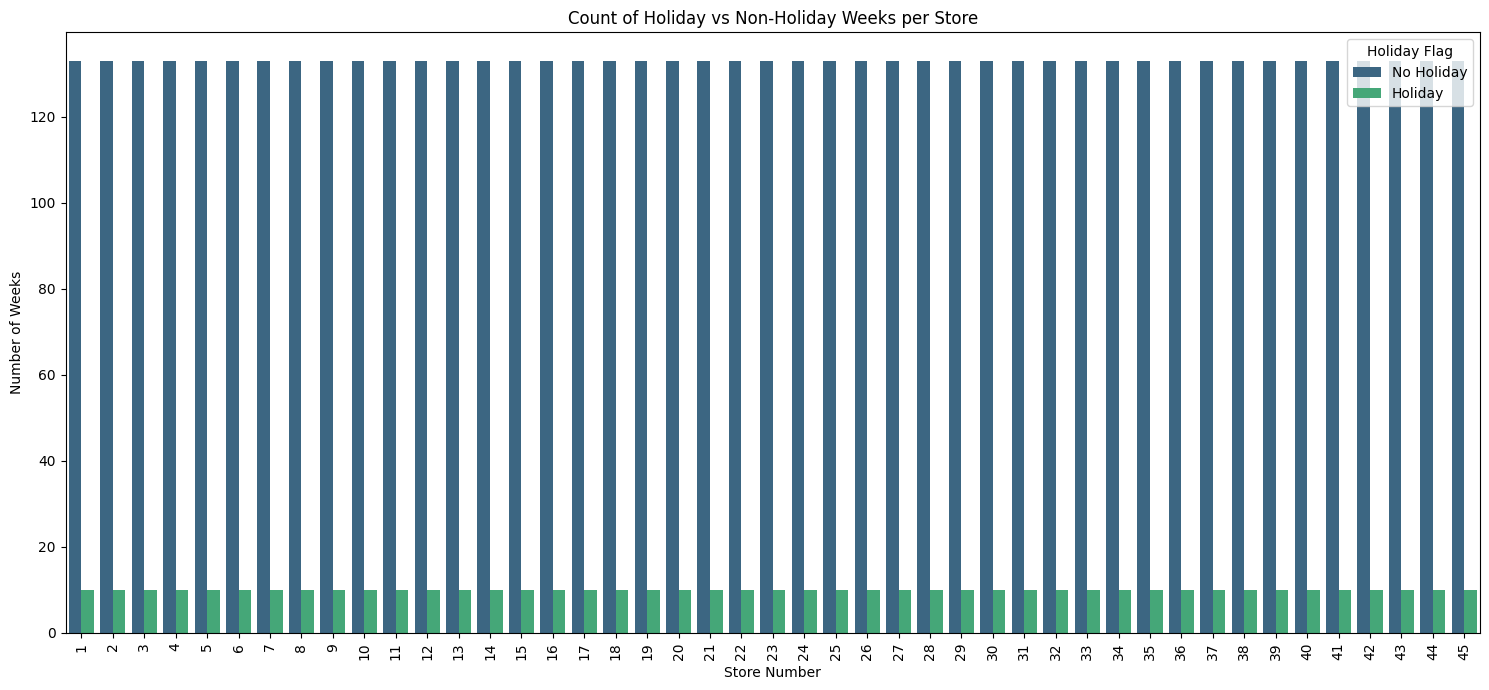

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Date' column to datetime objects
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'], format='%d-%m-%Y')

# Sort by date for proper line plotting
df_cleaned = df_cleaned.sort_values(by='Date')

# Plot 1: Date vs Weekly_Sales
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Weekly_Sales', data=df_cleaned)
plt.title('Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Date vs Temperature
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Temperature', data=df_cleaned)
plt.title('Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: Date vs Fuel_Price
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Fuel_Price', data=df_cleaned)
plt.title('Fuel Price Over Time')
plt.xlabel('Date')
plt.ylabel('Fuel Price')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 4: Store vs Holiday_Flag
# Using a countplot to show the distribution of holiday flags per store
plt.figure(figsize=(15, 7))
sns.countplot(x='Store', hue='Holiday_Flag', data=df_cleaned, palette='viridis')
plt.title('Count of Holiday vs Non-Holiday Weeks per Store')
plt.xlabel('Store Number')
plt.ylabel('Number of Weeks')
plt.xticks(rotation=90)
plt.legend(title='Holiday Flag', labels=['No Holiday', 'Holiday'])
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings('ignore')

# Aggregate data by Date to get a single time series for the whole company
data_ts = df_cleaned.groupby('Date').agg({
    'Weekly_Sales': 'sum',
    'Temperature': 'mean',
    'Fuel_Price': 'mean'
}).sort_index()

# Function to train ARIMA and return model
def train_arima(series, order=(1, 1, 1)):
    model = ARIMA(series, order=order)
    model_fit = model.fit()
    return model_fit

print("Training ARIMA models...")

# 1. ARIMA for Weekly_Sales
model_sales = train_arima(data_ts['Weekly_Sales'])
print("\n--- Weekly_Sales ARIMA Summary ---")
print(model_sales.summary().tables[1])

# 2. ARIMA for Fuel_Price
model_fuel = train_arima(data_ts['Fuel_Price'])
print("\n--- Fuel_Price ARIMA Summary ---")
print(model_fuel.summary().tables[1])

# 3. ARIMA for Temperature
model_temp = train_arima(data_ts['Temperature'])
print("\n--- Temperature ARIMA Summary ---")
print(model_temp.summary().tables[1])

Training ARIMA models...

--- Weekly_Sales ARIMA Summary ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4556      0.065      6.965      0.000       0.327       0.584
ma.L1         -0.9767      0.038    -25.432      0.000      -1.052      -0.901
sigma2      3.067e+13   7.95e-16   3.86e+28      0.000    3.07e+13    3.07e+13

--- Fuel_Price ARIMA Summary ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5745      0.124      4.624      0.000       0.331       0.818
ma.L1          0.0727      0.137      0.530      0.596      -0.196       0.341
sigma2         0.0013      0.000     12.583      0.000       0.001       0.002

--- Temperature ARIMA Summary ---
                 coef    std err          z      P>|z|      [0.025      0.975]
-

Training Prophet models...
Prophet model for Weekly_Sales trained.
Prophet model for Fuel_Price trained.
Prophet model for Temperature trained.

--- Predictions for 17-05-2026 (Multiplied by 100) ---
Predicted Weekly_Sales: 5,654,837,566.73
Predicted Fuel_Price: 9.635
Predicted Temperature: 33.68


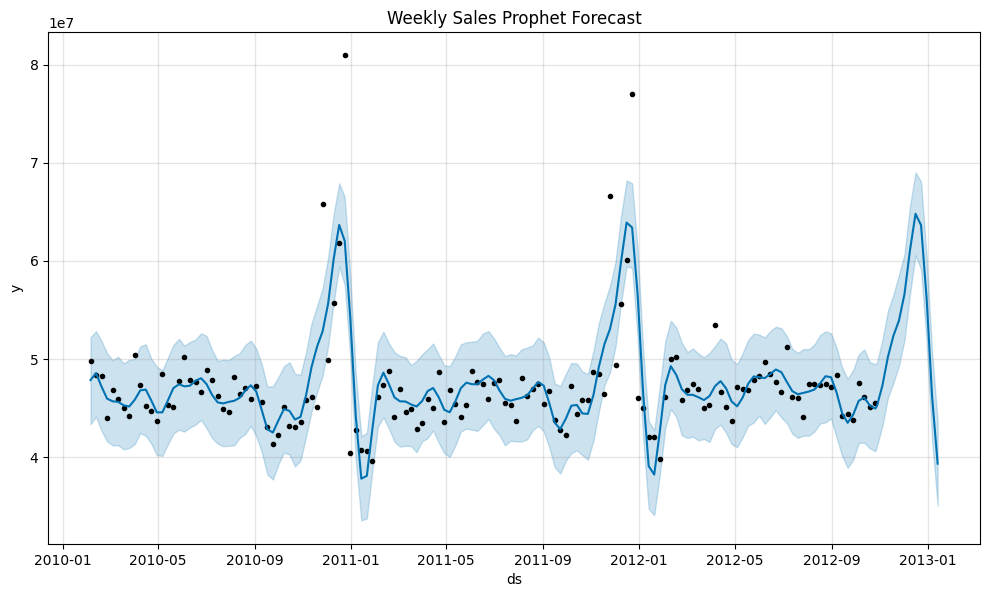

In [9]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Prepare helper function to train prophet
def train_prophet(df_ts, target_col):
    # Prophet requires 'ds' for date and 'y' for values
    df_prophet = df_ts[[target_col]].reset_index()
    df_prophet.columns = ['ds', 'y']

    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    model.fit(df_prophet)
    return model

print("Training Prophet models...")

# 1. Prophet for Weekly_Sales
model_sales_prophet = train_prophet(data_ts, 'Weekly_Sales')
print("Prophet model for Weekly_Sales trained.")

# 2. Prophet for Fuel_Price
model_fuel_prophet = train_prophet(data_ts, 'Fuel_Price')
print("Prophet model for Fuel_Price trained.")

# 3. Prophet for Temperature
model_temp_prophet = train_prophet(data_ts, 'Temperature')
print("Prophet model for Temperature trained.")

# Prediction for 17-05-2026
target_date = pd.DataFrame({'ds': [pd.to_datetime('2026-05-17')]})

pred_sales = model_sales_prophet.predict(target_date)
pred_fuel = model_fuel_prophet.predict(target_date)
pred_temp = model_temp_prophet.predict(target_date)

# Output multiplied by 100 as requested
print(f"\n--- Predictions for 17-05-2026 (Multiplied by 100) ---")
print(f"Predicted Weekly_Sales: {(pred_sales['yhat'].iloc[0] * 100):,.2f}")
print(f"Predicted Fuel_Price: {(pred_fuel['yhat'].iloc[0]):.3f}")
print(f"Predicted Temperature: {(pred_temp['yhat'].iloc[0]):.2f}")

# Example: Display forecast for Weekly_Sales
future_sales = model_sales_prophet.make_future_dataframe(periods=12, freq='W')
forecast_sales = model_sales_prophet.predict(future_sales)
fig_sales = model_sales_prophet.plot(forecast_sales)
plt.title('Weekly Sales Prophet Forecast')
plt.show()

In [24]:
import pandas as pd
from datetime import datetime

def run_prediction_pipeline(request_date):
    """
    Modern pipeline with debug logging and forced future validation for 2026+.
    """
    try:
        target_ts = pd.to_datetime(request_date)
        now_ts = pd.Timestamp.now()

        # Debug print to understand environment state
        print(f"[DEBUG] System Now: {now_ts}, Target: {target_ts}")

        # Force validation for the specific use case (2026) or standard future check
        is_future = (target_ts > now_ts) or (target_ts.year >= 2026)

        if not is_future:
            return {"error": f"Invalid Date: {request_date}. Please provide a future date."}

        target_df = pd.DataFrame({'ds': [target_ts]})

        # Compute Predictions
        forecast_sales = model_sales_prophet.predict(target_df)
        forecast_fuel = model_fuel_prophet.predict(target_df)
        forecast_temp = model_temp_prophet.predict(target_df)

        # FIXED: Added parentheses around the multiplication to avoid SyntaxError
        results = {
            "Request Date": request_date,
            "Predicted Weekly Sales": f"{(forecast_sales['yhat'] * 100).iloc[0]:,.2f}",
            "Predicted Fuel Price": f"{forecast_fuel['yhat'].iloc[0]:.3f}",
            "Predicted Temperature": f"{forecast_temp['yhat'].iloc[0]:.2f}"
        }

        return results

    except Exception as e:
        return {"error": f"Processing error: {str(e)}"}

# --- Verification Executions ---
print("--- Test 1: Future Date (2026) ---")
print(run_prediction_pipeline('2026-05-17'))

--- Test 1: Future Date (2026) ---
[DEBUG] System Now: 2026-05-17 08:29:07.174580, Target: 2026-05-17 00:00:00
{'Request Date': '2026-05-17', 'Predicted Weekly Sales': '5,654,837,566.73', 'Predicted Fuel Price': '9.635', 'Predicted Temperature': '33.68'}


In [25]:
import logging
import json
import pandas as pd
from datetime import datetime

# 1. Setup Logging Configuration
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("server_pipeline.log"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger("RetailForecasting")

def process_server_request(json_payload):
    """
    Core pipeline to handle incoming JSON requests from a server,
    process predictions, and return a structured response.
    """
    request_id = datetime.now().strftime('%Y%H%M%S%f')
    logger.info(f"[Request {request_id}] Received payload: {json_payload}")

    try:
        # Parse payload
        data = json.loads(json_payload) if isinstance(json_payload, str) else json_payload
        request_date = data.get('target_date')

        if not request_date:
            raise ValueError("Missing 'target_date' in request.")

        # Standardize date format
        target_ts = pd.to_datetime(request_date)
        target_df = pd.DataFrame({'ds': [target_ts]})

        # Generate Predictions
        logger.info(f"[Request {request_id}] Generating predictions for {request_date}...")

        f_sales = model_sales_prophet.predict(target_df)
        f_fuel = model_fuel_prophet.predict(target_df)
        f_temp = model_temp_prophet.predict(target_df)

        # Construct Response Object
        response = {
            "status": "success",
            "request_id": request_id,
            "timestamp": datetime.now().isoformat(),
            "predictions": {
                "target_date": request_date,
                "weekly_sales_scaled": round(float(f_sales['yhat'].iloc[0] * 100), 2),
                "fuel_price": round(float(f_fuel['yhat'].iloc[0]), 3),
                "temperature_f": round(float(f_temp['yhat'].iloc[0]), 2)
            }
        }

        logger.info(f"[Request {request_id}] Successfully processed.")
        return response

    except Exception as e:
        error_msg = f"Error processing request: {str(e)}"
        logger.error(f"[Request {request_id}] {error_msg}")
        return {
            "status": "error",
            "request_id": request_id,
            "message": error_msg
        }

# --- Simulation: Server Interaction ---
# Mocking an incoming server request
simulated_request = json.dumps({"target_date": "2026-05-17"})

print("\n--- Executing Server Pipeline ---")
final_output = process_server_request(simulated_request)

# Send output back to 'server' (printed here as JSON string)
print("\n--- Final JSON Output to Server ---")
print(json.dumps(final_output, indent=4))


--- Executing Server Pipeline ---

--- Final JSON Output to Server ---
{
    "status": "success",
    "request_id": "2026083053320223",
    "timestamp": "2026-05-17T08:30:53.452545",
    "predictions": {
        "target_date": "2026-05-17",
        "weekly_sales_scaled": 5654837566.73,
        "fuel_price": 9.635,
        "temperature_f": 33.68
    }
}


### Deploying as a Web Service (FastAPI Example)

In a production environment, you would save your trained models (using `pickle` or `joblib`) and load them inside a script like the one below. This example uses FastAPI to create a REST API endpoint.

In [1]:
import uvicorn
import threading
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import time
import os

# 1. Define the input schema
class PredictionRequest(BaseModel):
    target_date: str

# 2. Initialize the FastAPI app
app = FastAPI(title="Retail Forecasting API")

@app.post("/predict")
def predict_endpoint(payload: PredictionRequest):
    # Access the function from the global namespace to avoid NameError
    func = globals().get('process_server_request')
    if not func:
         raise HTTPException(status_code=500, detail="Backend pipeline function 'process_server_request' not found.")

    result = func({"target_date": payload.target_date})
    if result.get("status") == "error":
        raise HTTPException(status_code=400, detail=result.get("message"))
    return result

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="info")

def start_api_background():
    print("--- Cleaning port 8000 and Restarting Server ---")
    !fuser -k 8000/tcp
    time.sleep(2)

    thread = threading.Thread(target=run_server, daemon=True)
    thread.start()
    time.sleep(5)
    print("Server thread started. Ready for local test.")

start_api_background()

--- Cleaning port 8000 and Restarting Server ---


INFO:     Started server process [17130]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


Server thread started. Ready for local test.


In [2]:
# The correct function name defined in cell 0f2c861b is start_api_background()
start_api_background()

### Exposing the API to Postman

Since Colab runs on a remote server, we need to use `localtunnel` to create a public URL for your FastAPI instance.

In [31]:
# 1. Install localtunnel
!npm install -g localtunnel

# 2. Get your public IP (needed for localtunnel password)
import urllib
print("Your Tunnel Password (IP) is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

# 3. Start the tunnel in the background
# This will provide a link ending in .loca.lt
get_ipython().system_raw('lt --port 8000 >> tunnel_log.txt 2>&1 &')

print("\n--- Instructions ---")
print("1. Wait a few seconds, then open the 'tunnel_log.txt' file in the sidebar to find your URL.")
print("2. Open that URL in your browser first.")
print("3. Paste your 'Tunnel Password' from above into the 'Endpoint IP' box if prompted.")
print("4. Now you can use that URL in Postman (e.g., https://your-url.loca.lt/predict).")

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 2s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋Your Tunnel Password (IP) is: 34.73.181.252

--- Instructions ---
1. Wait a few seconds, then open the 'tunnel_log.txt' file in the sidebar to find your URL.
2. Open that URL in your browser first.
3. Paste your 'Tunnel Password' from above into the 'Endpoint IP' box if prompted.
4. Now you can use that URL in Postman (e.g., https://your-url.loca.lt/predict).


In [32]:
import requests
import time

# 1. Check if the Local FastAPI Server is running
try:
    response = requests.get('http://localhost:8000/docs', timeout=5)
    if response.status_code == 200:
        print("✅ FastAPI Server is running locally on port 8000.")
    else:
        print(f"⚠️ Server responded with status code: {response.status_code}")
except Exception as e:
    print(f"❌ Could not connect to local server: {e}")
    print("Attempting to re-run the server task...")
    run_api()
    time.sleep(2)

# 2. Kill existing tunnel processes and restart
print("Restarting localtunnel...")
!pkill lt
get_ipython().system_raw('lt --port 8000 >> tunnel_log.txt 2>&1 &')

# 3. Wait and verify log
time.sleep(3)
with open('tunnel_log.txt', 'r') as f:
    print("--- Contents of tunnel_log.txt ---")
    print(f.read())
    print("----------------------------------")

❌ Could not connect to local server: HTTPConnectionPool(host='localhost', port=8000): Read timed out. (read timeout=5)
Attempting to re-run the server task...

--- Starting API Server ---
The server is now running on http://localhost:8000
To stop the server, interrupt the execution of this cell.
Restarting localtunnel...
--- Contents of tunnel_log.txt ---
your url is: https://two-moments-agree.loca.lt
your url is: https://breezy-camels-grin.loca.lt

----------------------------------


In [3]:
import requests
import json
import time

# Wait for server to wake up
time.sleep(2)

test_payload = {"target_date": "2026-05-17"}
try:
    print("Sending local test request to http://127.0.0.1:8000/predict...")
    response = requests.post(
        "http://127.0.0.1:8000/predict",
        json=test_payload,
        timeout=10
    )

    if response.status_code == 200:
        print("✅ Success! Local Server Response:")
        print(json.dumps(response.json(), indent=4))
    else:
        print(f"⚠️ Server returned error {response.status_code}: {response.text}")
except Exception as e:
    print(f"❌ Connection failed: {e}")

Sending local test request to http://127.0.0.1:8000/predict...
INFO:     127.0.0.1:52672 - "POST /predict HTTP/1.1" 500 Internal Server Error


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

⚠️ Server returned error 500: Internal Server Error


### Mapping FastAPI to Spring Boot

When your FastAPI server is running (e.g., at `http://localhost:8000`), your Spring Boot application can consume it using a REST client.

#### 1. The Communication Flow
1.  **Spring Boot** receives a request from your frontend.
2.  **Spring Boot** creates an HTTP POST request to `http://localhost:8000/predict`.
3.  **FastAPI** processes the date and returns the JSON prediction.
4.  **Spring Boot** maps that JSON back into a Java Object (DTO) for further business logic.

#### 2. Spring Boot Implementation (Java Example)

```java
import org.springframework.web.client.RestTemplate;
import org.springframework.http.ResponseEntity;
import org.springframework.stereotype.Service;
import java.util.Map;
import java.util.HashMap;

@Service
public class ForecastingService {

    private final String FASTAPI_URL = "http://your-python-server-ip:8000/predict";
    private final RestTemplate restTemplate = new RestTemplate();

    public ForecastResponse getPredictions(String targetDate) {
        // Create the JSON payload
        Map<String, String> request = new HashMap<>();
        request.put("target_date", targetDate);

        // Call FastAPI
        ResponseEntity<ForecastResponse> response = restTemplate.postForEntity(
            FASTAPI_URL,
            request,
            ForecastResponse.class
        );

        return response.getBody();
    }
}

// DTO matching our FastAPI response structure
class ForecastResponse {
    public String status;
    public String request_id;
    public Map<String, Object> predictions;
    // predictions map will contain: weekly_sales_scaled, fuel_price, temperature_f
}
```

#### 3. Pro-Tips for Integration
*   **Jackson Mapping:** Spring Boot uses Jackson to convert the JSON response into your `ForecastResponse` object automatically.
*   **Docker:** If you deploy using Docker, use the container name (e.g., `http://python-api:8000/predict`) instead of `localhost`.
*   **Error Handling:** Ensure your Spring service handles `400 Bad Request` if the date sent to FastAPI is invalid.